# FastRisk2 Framework Demo

This notebook demonstrates key capabilities:
- Load a small portfolio (JSON), price scenarios, and compute VaR via multiple methods
- Pricers via dynamic loading and invoke-style factory
- Pricing scenarios and VaR



In [15]:
# Setup paths and imports (robust to different working dirs)
import os, sys
from pathlib import Path


def add_project_root_to_sys_path() -> str:
    cwd = Path(os.getcwd()).resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
    ]
    # If running from notebooks/, include its parent
    try:
        nb_parent = Path(__file__).resolve().parent.parent
        candidates.append(nb_parent)
    except Exception:
        candidates.append(cwd.parent)
    for d in candidates:
        if (d / 'product_definitions.py').exists():
            if str(d) not in sys.path:
                sys.path.insert(0, str(d))
            return str(d)
    # Fallback: insert cwd
    if str(cwd) not in sys.path:
        sys.path.insert(0, str(cwd))
    return str(cwd)

proj_root = add_project_root_to_sys_path()

from datetime import date
import numpy as np
import QuantLib as ql

from product_definitions import (
    QuantLibBondStaticBase, CallableBondStaticBase, ConvertibleBondStaticBase,
)
from pricers import create_pricer
from quantlib_bond_pricer import QuantLibBondPricer
from scenario_generator import SimpleRandomScenarioGenerator
print(f"Project root on sys.path: {proj_root}")



Project root on sys.path: /Users/gordonlee/Documents/FastRisk2


In [16]:
# 1) Pricers via dynamic loading (invoke-style factory)

val_date = date(2025, 6, 15)
ql.Settings.instance().evaluationDate = ql.Date(val_date.day, val_date.month, val_date.year)

vanilla = QuantLibBondStaticBase(
    valuation_date=val_date,
    maturity_date=date(2030, 6, 15),
    coupon_rate=0.03,
    face_value=100.0,
    freq=2,
    currency='USD',
    index_stub='GENERIC_IR'
)

# Dynamic pricer creation: QuantLib-based pricer
ql_pricer_cfg = {
    'pricer_module_name': 'quantlib_bond_pricer',
    'pricer_class_name': 'QuantLibBondPricer',
    'pricer_params': {'method': 'discount'}
}
ql_pricer = create_pricer(vanilla, ql_pricer_cfg)

pillars = np.array([0.50, 1.00, 2.00, 5.00, 10.00], dtype=float)
rates = np.array([0.02, 0.022, 0.024, 0.026, 0.028], dtype=float)

# price example
price_ql = np.atleast_1d(ql_pricer.price(pillars, rates))[0]
price_ql


np.float64(101.82069838777734)

In [25]:
# 2) Pricing scenarios and simple VaR

# Build factor names expected by QuantLibBondPricer for these pillars
factor_names = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars]

# Scenario generator configured with base values for those factors
base_rates_map = {name: val for name, val in zip(factor_names, rates)}
sg = SimpleRandomScenarioGenerator(
    base_rates_map=base_rates_map,
    rate_factor_shock_std_dev_map={name: 0.002 for name in factor_names},
    random_seed=123
)

num_scen = 2000
scenarios, names = sg.generate_scenarios(num_scen, target_factor_names=factor_names)

# Price scenarios with the QL pricer
prices = ql_pricer.price_scenarios(scenarios, names, rate_pillars=pillars)

# Compute simple historical VaR (e.g., 95%) on PnL relative to base
base_price = ql_pricer.price(pillars, rates)[0]
pnl = prices - base_price
var95 = np.percentile(pnl, 5)
base_price, pnl.mean(), var95


(np.float64(101.82069838777734),
 np.float64(0.009012272779746588),
 np.float64(-1.5274723792654306))

In [26]:
# 3) Example: perturb base curve and reprice with QuantLib pricer

rng = np.random.default_rng(42)
curves = rates + rng.normal(0.0, 0.0015, size=rates.shape)

ql_prices = np.atleast_1d(ql_pricer.price(pillars, curves))
base_price = np.atleast_1d(ql_pricer.price(pillars, rates))

abs_diff = float(np.abs(ql_prices[0] - base_price[0]))
rel_bp = (abs_diff / base_price[0]) * 10000.0
ql_prices[0], base_price[0], abs_diff, rel_bp


(np.float64(101.165271836929),
 np.float64(101.82069838777734),
 0.6554265508483468,
 np.float64(64.37065952466742))

Notes:
- Dynamic loading uses `pricers.create_pricer` and `custom_importer` to load classes by module/class name.
- Scenario pricing uses expected factor naming convention `CCY_INDEX_STUB_<Tenor>Y`.
- Fast pricer (TFF-like) aims to match QL prices within a few cents under small curve perturbations; RBFI can be integrated similarly if available (see `rbfi_approximator.py`).



In [ ]:
# Visualization setup
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

## Callable and Convertible Bonds
We'll instantiate callable and convertible bonds and price them. For callable bonds we use the G2 tree engine; for convertibles we supply equity inputs and a credit spread for the engine.


In [20]:
# Callable Bond example (G2 model)
callable_static = CallableBondStaticBase(
    valuation_date=val_date,
    maturity_date=date(2030, 6, 15),
    coupon_rate=0.035,
    face_value=100.0,
    freq=2,
    call_dates=[date(2027,6,15).isoformat(), date(2028,6,15).isoformat(), date(2029,6,15).isoformat()],
    call_prices=[102.0, 101.0, 100.5],
    calendar='target', day_count='Actual/Actual (ISDA)'
)
callable_pricer = create_pricer(callable_static, {
    'pricer_module_name': 'quantlib_bond_pricer',
    'pricer_class_name': 'QuantLibBondPricer',
    'pricer_params': {'method': 'g2', 'grid_steps': 64}
})

# Reuse rate pillars
g2_params = (0.01, 0.003, 0.015, 0.006, -0.75)
callable_price = callable_pricer.price(pillars, rates, g2_params=g2_params)[0]
callable_price


np.float64(103.34707988163575)

In [21]:
# Convertible Bond example
convertible_static = ConvertibleBondStaticBase(
    valuation_date=val_date,
    issue_date=date(2024, 6, 15),
    maturity_date=date(2030, 6, 15),
    coupon_rate=0.02,
    conversion_ratio=1.0,
    face_value=100.0,
    freq=2,
    calendar='target', day_count='Actual/Actual (ISDA)',
    underlying_symbol='AAPL',
)

convertible_pricer = create_pricer(convertible_static, {
    'pricer_module_name': 'quantlib_bond_pricer',
    'pricer_class_name': 'QuantLibBondPricer',
    'pricer_params': {'method': 'discount', 'convertible_engine_steps': 64}
})

cb_price = convertible_pricer.price(
    pillars, rates,
    s0_val=100.0, dividend_yield=0.01, equity_volatility=0.25, credit_spread=0.002
)[0]
cb_price


np.float64(120.08222968002795)

## Visualizing scenario PnL and VaR
We'll reuse the previously generated scenarios to visualize the distribution of PnL for the vanilla bond and compute VaR. Then we'll compare callable and convertible sensitivity to a simple rate shift.


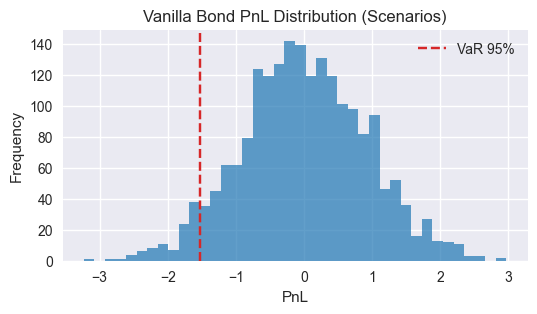

np.float64(-1.5274723792654306)

In [22]:
# Ensure we have scenarios and prices for the vanilla bond from Section 2
if 'scenarios' not in locals():
    factor_names = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars]
    base_rates_map = {name: val for name, val in zip(factor_names, rates)}
    sg = SimpleRandomScenarioGenerator(
        base_rates_map=base_rates_map,
        rate_factor_shock_std_dev_map={name: 0.002 for name in factor_names},
        random_seed=123
    )
    scenarios, names = sg.generate_scenarios(2000, target_factor_names=factor_names)

vanilla_prices = ql_pricer.price_scenarios(scenarios, names, rate_pillars=pillars)
base_price = np.atleast_1d(ql_pricer.price(pillars, rates))[0]
pnl = vanilla_prices - base_price

fig, ax = plt.subplots(figsize=(6,3))
ax.hist(pnl, bins=40, alpha=0.7, color='tab:blue')
ax.axvline(np.percentile(pnl,5), color='tab:red', linestyle='--', label='VaR 95%')
ax.set_title('Vanilla Bond PnL Distribution (Scenarios)')
ax.set_xlabel('PnL'); ax.set_ylabel('Frequency'); ax.legend(); plt.show()

var95 = np.percentile(pnl,5)
var95


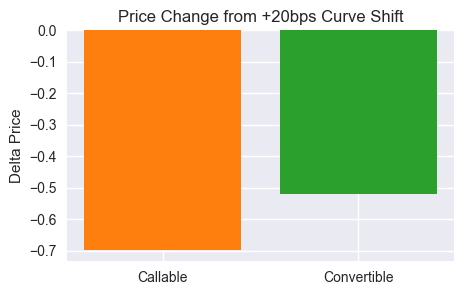

[np.float64(-0.6992237321466632), np.float64(-0.5196439365685421)]

In [23]:
# Rate shift sensitivity visualization for callable and convertible
shift = 0.002  # +20 bps parallel
rates_up = rates + shift

callable_p0 = callable_pricer.price(pillars, rates, g2_params=g2_params)[0]
callable_p1 = callable_pricer.price(pillars, rates_up, g2_params=g2_params)[0]
convertible_p0 = convertible_pricer.price(pillars, rates, s0_val=100.0, dividend_yield=0.01, equity_volatility=0.25, credit_spread=0.002)[0]
convertible_p1 = convertible_pricer.price(pillars, rates_up, s0_val=100.0, dividend_yield=0.01, equity_volatility=0.25, credit_spread=0.002)[0]

labels = ['Callable', 'Convertible']
delta = [callable_p1 - callable_p0, convertible_p1 - convertible_p0]

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(labels, delta, color=['tab:orange','tab:green'])
ax.set_title('Price Change from +20bps Curve Shift')
ax.set_ylabel('Delta Price'); plt.show()

delta


## FRN and ILB Examples
We also support Floating Rate Bonds (FRN) and Inflation Linked Bonds (ILB). Below, we show examples and visualize how price changes with spread (FRN) and with inflation assumptions (ILB).


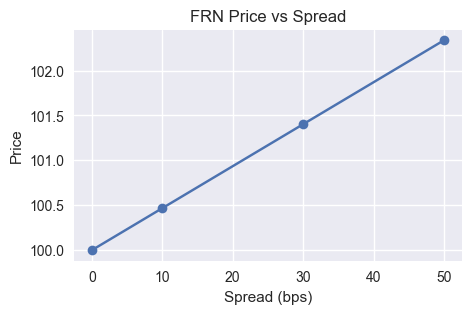

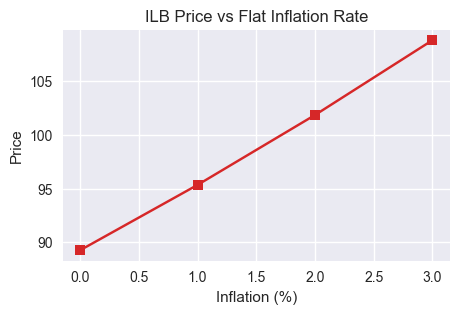

In [24]:
from product_definitions import FloatingRateBondStaticBase, InflationLinkedBondStaticBase

# FRN: price vs spread
frn_static = FloatingRateBondStaticBase(
    valuation_date=val_date, maturity_date=date(2030,6,15),
    coupon_rate=0.0, face_value=100.0, freq=4, index_tenor_months=3, spread=0.0
)
frn_pricer = create_pricer(frn_static, {
    'pricer_module_name': 'quantlib_bond_pricer',
    'pricer_class_name': 'QuantLibBondPricer',
    'pricer_params': {'method': 'discount'}
})

spreads = np.array([0.0, 0.001, 0.003, 0.005])
frn_prices = [frn_pricer.price(pillars, rates, )[0] if s==0 else 
              create_pricer(FloatingRateBondStaticBase(
                  valuation_date=val_date, maturity_date=date(2030,6,15),
                  coupon_rate=0.0, face_value=100.0, freq=4, index_tenor_months=3, spread=float(s)
              ), {'pricer_module_name':'quantlib_bond_pricer','pricer_class_name':'QuantLibBondPricer','pricer_params':{'method':'discount'}}).price(pillars, rates)[0]
             for s in spreads]

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(spreads*1e4, frn_prices, marker='o')
ax.set_title('FRN Price vs Spread'); ax.set_xlabel('Spread (bps)'); ax.set_ylabel('Price'); plt.show()

# ILB: price vs inflation rate (flat)
ilb_static = InflationLinkedBondStaticBase(
    valuation_date=val_date, maturity_date=date(2032,6,15),
    coupon_rate=0.01, face_value=100.0, freq=2,
    inflation_factor_name='USD_INFLATION', inflation_compounding='continuous', inflation_lag_months=2
)
ilb_pricer = create_pricer(ilb_static, {
    'pricer_module_name': 'quantlib_bond_pricer',
    'pricer_class_name': 'QuantLibBondPricer',
    'pricer_params': {'method': 'discount'}
})

infl_rates = np.array([0.0, 0.01, 0.02, 0.03])
ilb_prices = [ilb_pricer.price(pillars, rates, inflation_rate=float(ir))[0] for ir in infl_rates]

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(infl_rates*100, ilb_prices, marker='s', color='tab:red')
ax.set_title('ILB Price vs Flat Inflation Rate'); ax.set_xlabel('Inflation (%)'); ax.set_ylabel('Price'); plt.show()


## Explanations
- Dynamic loading: use `create_pricer` with module/class names to instantiate pricers at runtime, enabling plug-and-play engines.
- Scenario pricing: factor names follow `CCY_INDEX_STUB_<Tenor>Y`. Use `price_scenarios` to align scenario matrices without manual slicing.
- Callable pricing: G2 model introduces rate volatility; CTW is a static approximation. Expect small but nonzero differences.
- Convertible pricing: requires equity inputs (S0, dividend yield, volatility) and a credit spread for the engine.
- FRN pricing: coupons float off the forward curve plus spread; price increases with spread.
- ILB pricing: cashflows scaled by inflation factor (continuous/annual compounding) with an indexation lag; supports flat/piecewise inputs.


## TFF and RBFI Approximation Demonstration
We will calibrate Tensor Functional Form (TFF) and Radial Basis Function Interpolator (RBFI) surrogates for the vanilla bond around the base curve and compare accuracy.


In [27]:
from tff_approximator import TensorFunctionalFormCalibrate
from rbfi_approximator import RBFICalibrate

# Prepare factors for the vanilla bond: use the same rate pillars as factors
factor_names_tff = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars]
base_values_tff = rates.copy()

# pricer template (same as ql_pricer) for calibration
pricer_template = ql_pricer

# Build calibrators
tff_cal = TensorFunctionalFormCalibrate(
    pricer_template=pricer_template,
    tff_input_raw_factor_names=factor_names_tff,
    tff_input_raw_base_values=base_values_tff,
    product_static_params_for_worker=vanilla.to_dict(),
    pricer_config_for_worker={'bond_pricer_config': {'method': 'discount'}},
    actual_rate_pillars=pillars
)

rbfi_cal = RBFICalibrate(
    pricer_template=pricer_template,
    rbfi_input_raw_factor_names=factor_names_tff,
    rbfi_input_raw_base_values=base_values_tff,
    product_static_params_for_worker=vanilla.to_dict(),
    pricer_config_for_worker={'bond_pricer_config': {'method': 'discount'}},
    actual_rate_pillars=pillars
)

# Generate a domain of scenarios around the base curve for calibration/testing
rng = np.random.default_rng(123)
domain = np.vstack([
    rates + rng.normal(0.0, 0.0015, size=rates.shape) for _ in range(256)
])

tff_model, tff_Xtest, tff_true, tff_rmse, tff_norm, tff_base_true, tff_base_pred = tff_cal.sample_and_fit(
    full_market_scenarios_for_tff_factors=domain,
    n_train=64, n_test=16, random_seed=1, order=2
)

rbfi_model, rbfi_Xtest, rbfi_true, rbfi_rmse, rbfi_norm, rbfi_base_true, rbfi_base_pred = rbfi_cal.sample_and_fit(
    full_market_scenarios_for_rbfi_factors=domain,
    n_train=64, n_test=16, random_seed=1, length_scale_method='auto'
)

print({'tff_rmse': float(tff_rmse), 'rbfi_rmse': float(rbfi_rmse)})


{'tff_rmse': 1.632414955773474e-05, 'rbfi_rmse': 0.000569532067397852}


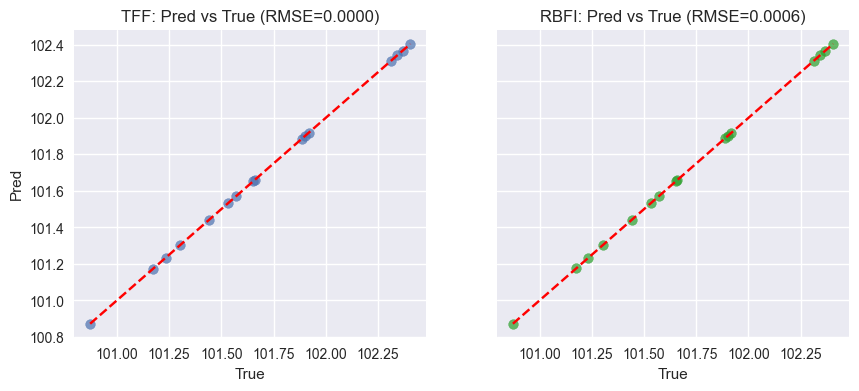

{'tff_base_diff': 0.16047342876272808, 'rbfi_base_diff': 0.16129612418096428}

In [29]:
# Visualize predicted vs true for TFF and RBFI on test set
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
axes[0].scatter(tff_true, tff_model(tff_Xtest), alpha=0.7)
axes[0].plot([tff_true.min(), tff_true.max()], [tff_true.min(), tff_true.max()], 'r--')
axes[0].set_title(f'TFF: Pred vs True (RMSE={tff_rmse:.4f})')
axes[0].set_xlabel('True'); axes[0].set_ylabel('Pred')

axes[1].scatter(rbfi_true, rbfi_model(rbfi_Xtest), alpha=0.7, color='tab:green')
axes[1].plot([rbfi_true.min(), rbfi_true.max()], [rbfi_true.min(), rbfi_true.max()], 'r--')
axes[1].set_title(f'RBFI: Pred vs True (RMSE={rbfi_rmse:.4f})')
axes[1].set_xlabel('True')
plt.show()

{'tff_base_diff': float(tff_base_pred - tff_base_true), 'rbfi_base_diff': float(rbfi_base_pred - rbfi_base_true)}


## TFF/RBFI for Callable and Convertible Bonds
We now calibrate TFF and RBFI surrogates for the callable (G2) and convertible bonds around the base curve (rates only), keeping model-specific parameters fixed.


In [30]:
# Shared factor setup for both products
ccy_factor_names = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars]
base_vals = rates.copy()

# Callable: TFF/RBFI calibration (rates only; G2 params fixed)
from tff_approximator import TensorFunctionalFormCalibrate
from rbfi_approximator import RBFICalibrate

callable_params_dict = callable_static.to_dict()
callable_price_kwargs = {'g2_params': g2_params}
callable_pricer_template = callable_pricer

callable_tff = TensorFunctionalFormCalibrate(
    pricer_template=callable_pricer_template,
    tff_input_raw_factor_names=ccy_factor_names,
    tff_input_raw_base_values=base_vals,
    product_static_params_for_worker=callable_params_dict,
    pricer_config_for_worker={'bond_pricer_config': {'method': 'g2', 'grid_steps': 64}},
    actual_rate_pillars=pillars
)

callable_rbfi = RBFICalibrate(
    pricer_template=callable_pricer_template,
    rbfi_input_raw_factor_names=ccy_factor_names,
    rbfi_input_raw_base_values=base_vals,
    product_static_params_for_worker=callable_params_dict,
    pricer_config_for_worker={'bond_pricer_config': {'method': 'g2', 'grid_steps': 64}},
    actual_rate_pillars=pillars
)

rng = np.random.default_rng(321)
call_domain = np.vstack([rates + rng.normal(0.0, 0.0015, size=rates.shape) for _ in range(256)])

call_tff_model, call_Xtest, call_true, call_rmse, _, call_base_true, call_base_pred = callable_tff.sample_and_fit(
    full_market_scenarios_for_tff_factors=call_domain,
    n_train=64, n_test=16, random_seed=7, order=2, **callable_price_kwargs
)

call_rbfi_model, call_Xtest2, call_true2, call_rbfi_rmse, _, call_base_true2, call_base_pred2 = callable_rbfi.sample_and_fit(
    full_market_scenarios_for_rbfi_factors=call_domain,
    n_train=64, n_test=16, random_seed=7, **callable_price_kwargs
)

print({'callable_tff_rmse': float(call_rmse), 'callable_rbfi_rmse': float(call_rbfi_rmse)})


{'callable_tff_rmse': 0.018266142458775603, 'callable_rbfi_rmse': 0.018227342473369528}


In [31]:
# Convertible: TFF/RBFI calibration (rates only; equity params fixed)
conv_params_dict = convertible_static.to_dict()
conv_price_kwargs = {'s0_val': 100.0, 'dividend_yield': 0.01, 'equity_volatility': 0.25, 'credit_spread': 0.002}
conv_pricer_template = convertible_pricer

conv_tff = TensorFunctionalFormCalibrate(
    pricer_template=conv_pricer_template,
    tff_input_raw_factor_names=ccy_factor_names,
    tff_input_raw_base_values=base_vals,
    product_static_params_for_worker=conv_params_dict,
    pricer_config_for_worker={'bond_pricer_config': {'method': 'discount', 'convertible_engine_steps': 64}},
    actual_rate_pillars=pillars
)

conv_rbfi = RBFICalibrate(
    pricer_template=conv_pricer_template,
    rbfi_input_raw_factor_names=ccy_factor_names,
    rbfi_input_raw_base_values=base_vals,
    product_static_params_for_worker=conv_params_dict,
    pricer_config_for_worker={'bond_pricer_config': {'method': 'discount', 'convertible_engine_steps': 64}},
    actual_rate_pillars=pillars
)

rng = np.random.default_rng(456)
conv_domain = np.vstack([rates + rng.normal(0.0, 0.0015, size=rates.shape) for _ in range(256)])

conv_tff_model, conv_Xtest, conv_true, conv_rmse, _, conv_base_true, conv_base_pred = conv_tff.sample_and_fit(
    full_market_scenarios_for_tff_factors=conv_domain,
    n_train=64, n_test=16, random_seed=9, order=2, **conv_price_kwargs
)

conv_rbfi_model, conv_Xtest2, conv_true2, conv_rbfi_rmse, _, conv_base_true2, conv_base_pred2 = conv_rbfi.sample_and_fit(
    full_market_scenarios_for_rbfi_factors=conv_domain,
    n_train=64, n_test=16, random_seed=9, **conv_price_kwargs
)

print({'convertible_tff_rmse': float(conv_rmse), 'convertible_rbfi_rmse': float(conv_rbfi_rmse)})


{'convertible_tff_rmse': 4.86641583808423e-05, 'convertible_rbfi_rmse': 0.0006788241761268251}


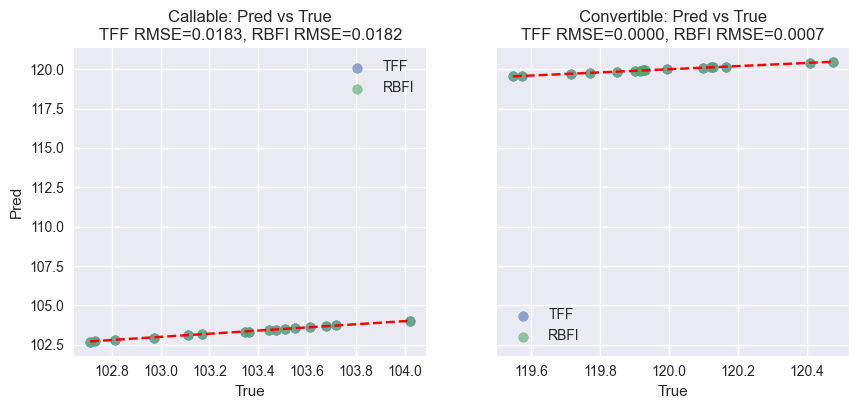

{'call_base_diff_tff': -0.6969985212442822,
 'call_base_diff_rbfi': -0.6971689602842588,
 'conv_base_diff_tff': -0.014486494585014498,
 'conv_base_diff_rbfi': -0.01343068303850714}

In [32]:
# Visualize Pred vs True for Callable and Convertible
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
axes[0].scatter(call_true, call_tff_model(call_Xtest), alpha=0.6, label='TFF')
axes[0].scatter(call_true2, call_rbfi_model(call_Xtest2), alpha=0.6, label='RBFI')
axes[0].plot([min(call_true.min(), call_true2.min()), max(call_true.max(), call_true2.max())],
             [min(call_true.min(), call_true2.min()), max(call_true.max(), call_true2.max())], 'r--')
axes[0].set_title(f'Callable: Pred vs True\nTFF RMSE={call_rmse:.4f}, RBFI RMSE={call_rbfi_rmse:.4f}')
axes[0].set_xlabel('True'); axes[0].set_ylabel('Pred'); axes[0].legend()

axes[1].scatter(conv_true, conv_tff_model(conv_Xtest), alpha=0.6, label='TFF')
axes[1].scatter(conv_true2, conv_rbfi_model(conv_Xtest2), alpha=0.6, label='RBFI')
axes[1].plot([min(conv_true.min(), conv_true2.min()), max(conv_true.max(), conv_true2.max())],
             [min(conv_true.min(), conv_true2.min()), max(conv_true.max(), conv_true2.max())], 'r--')
axes[1].set_title(f'Convertible: Pred vs True\nTFF RMSE={conv_rmse:.4f}, RBFI RMSE={conv_rbfi_rmse:.4f}')
axes[1].set_xlabel('True'); axes[1].legend()
plt.show()

{
 'call_base_diff_tff': float(call_base_pred - call_base_true),
 'call_base_diff_rbfi': float(call_base_pred2 - call_base_true2),
 'conv_base_diff_tff': float(conv_base_pred - conv_base_true),
 'conv_base_diff_rbfi': float(conv_base_pred2 - conv_base_true2)
}


## Portfolio VaR from JSON (Baseline vs TFF vs RBFI vs Hybrid)
We'll start with a small mixed portfolio loaded from JSON, build scenario PnL, and compute VaR using:
- Baseline QuantLib pricing
- TFF surrogate (vanilla-only example for simplicity)
- RBFI surrogate (vanilla-only example)
- Hybrid: use surrogates for vanilla bonds, full pricers for callable/convertibles


In [50]:
import json
from product_definitions import reconstruct_product_static

# Load portfolio
portfolio_path = os.path.join(proj_root, 'notebooks', 'data', 'portfolio_small.json')
with open(portfolio_path, 'r') as f:
    portfolio_data = json.load(f)

# Build statics and pricers
statics = [reconstruct_product_static(d) for d in portfolio_data]
pricers_list = []
for st in statics:
    if st.__class__.__name__ == 'CallableBondStaticBase':
        cfg = {'pricer_module_name': 'quantlib_bond_pricer', 'pricer_class_name': 'QuantLibBondPricer', 'pricer_params': {'method':'g2','grid_steps':64}}
    elif st.__class__.__name__ == 'ConvertibleBondStaticBase':
        cfg = {'pricer_module_name': 'quantlib_bond_pricer', 'pricer_class_name': 'QuantLibBondPricer', 'pricer_params': {'method':'discount','convertible_engine_steps':64}}
    else:
        cfg = {'pricer_module_name': 'quantlib_bond_pricer', 'pricer_class_name': 'QuantLibBondPricer', 'pricer_params': {'method':'discount'}}
    pricers_list.append(create_pricer(st, cfg))

# Scenario setup
pillars_port = pillars
factor_names_port = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars_port]
base_rates_map = {n: v for n, v in zip(factor_names_port, rates)}
sg = SimpleRandomScenarioGenerator(
    base_rates_map=base_rates_map,
    rate_factor_shock_std_dev_map={n: 0.002 for n in factor_names_port},
    random_seed=999
)

num_scen = 200
scen, names = sg.generate_scenarios(num_scen, target_factor_names=factor_names_port)

# Market aux params
g2_params = (0.01, 0.003, 0.015, 0.006, -0.75)
conv_kwargs = {'s0_val': 100.0, 'dividend_yield': 0.01, 'equity_volatility': 0.25, 'credit_spread': 0.002}

# Baseline portfolio pricing per scenario
base_values = []
for st, pr in zip(statics, pricers_list):
    if st.__class__.__name__ == 'ConvertibleBondStaticBase':
        vals = pr.price_scenarios(scen, names, rate_pillars=pillars_port, **conv_kwargs)
    elif st.__class__.__name__ == 'CallableBondStaticBase':
        vals = pr.price_scenarios(scen, names, rate_pillars=pillars_port, g2_params=g2_params)
    else:
        vals = pr.price_scenarios(scen, names, rate_pillars=pillars_port)
    base_values.append(vals)

# Portfolio aggregation (equal notionals)
baseline_port_prices = np.sum(np.vstack(base_values), axis=0)
baseline_port_base = baseline_port_prices[0]
baseline_port_pnl = baseline_port_prices - baseline_port_base
baseline_var95 = np.percentile(baseline_port_pnl, 5)
float(baseline_var95)


ValueError: S0 factor 'USD_AAPL_S0' not found in scenario factor names.

In [48]:
# Rebuild scenarios including equity factors needed for convertible pricing
rate_factor_names = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars]
conv_equity_names = ['USD_AAPL_S0', 'USD_AAPL_DIVYIELD', 'USD_AAPL_VOL', 'USD_AAPL_CS']
factor_names_port = rate_factor_names + conv_equity_names

sg = SimpleRandomScenarioGenerator(
    base_rates_map={n: v for n, v in zip(rate_factor_names, rates)},
    rate_factor_shock_std_dev_map={n: 0.002 for n in rate_factor_names},
    base_s0_map={'USD_AAPL_S0': 100.0, 'USD_AAPL_DIVYIELD': 0.01, 'USD_AAPL_CS': 0.002},
    s0_shock_config_map={'USD_AAPL_S0': ('normal_relative', 0.02), 'USD_AAPL_DIVYIELD': ('normal_absolute', 0.002), 'USD_AAPL_CS': ('normal_absolute', 0.0005)},
    base_vol_map={'USD_AAPL_VOL': 0.25},
    vol_shock_config_map={'USD_AAPL_VOL': ('normal_relative', 0.10)},
    random_seed=999
)

num_scen = 200
scen, names = sg.generate_scenarios(num_scen, target_factor_names=factor_names_port)

# Recompute baseline portfolio prices with updated scenarios
base_values = []
for st, pr in zip(statics, pricers_list):
    if st.__class__.__name__ == 'ConvertibleBondStaticBase':
        vals = pr.price_scenarios(scen, names, rate_pillars=pillars, **conv_kwargs)
    elif st.__class__.__name__ == 'CallableBondStaticBase':
        vals = pr.price_scenarios(scen, names, rate_pillars=pillars, g2_params=g2_params)
    else:
        vals = pr.price_scenarios(scen, names, rate_pillars=pillars)
    base_values.append(vals)

baseline_port_prices = np.sum(np.vstack(base_values), axis=0)
baseline_port_base = baseline_port_prices[0]
baseline_port_pnl = baseline_port_prices - baseline_port_base
baseline_var95 = np.percentile(baseline_port_pnl, 5)
float(baseline_var95)


-5.67011175460291

In [51]:
# TFF/RBFI surrogates for vanilla bonds only; full pricing for callable/convertible (Hybrid)
from tff_approximator import TensorFunctionalFormCalibrate
from rbfi_approximator import RBFICalibrate

# Identify vanilla indices
vanilla_idx = [i for i, st in enumerate(statics) if st.__class__.__name__ == 'QuantLibBondStaticBase']

# Calibrate one surrogate per vanilla instrument
surrogates_tff = {}
surrogates_rbfi = {}
for i in vanilla_idx:
    st = statics[i]
    pr = pricers_list[i]
    names_v = [f"USD_GENERIC_IR_{t:.2f}Y" for t in pillars_port]
    base_v = rates.copy()
    domain_v = np.vstack([rates + np.random.default_rng(111+i).normal(0.0, 0.0015, size=rates.shape) for _ in range(128)])

    tff_cal = TensorFunctionalFormCalibrate(
        pricer_template=pr,
        tff_input_raw_factor_names=names_v,
        tff_input_raw_base_values=base_v,
        product_static_params_for_worker=st.to_dict(),
        pricer_config_for_worker={'bond_pricer_config': {'method': 'discount'}},
        actual_rate_pillars=pillars_port
    )
    tff_model, Xtest, true_p, rmse_tff, _, base_true, base_pred = tff_cal.sample_and_fit(
        full_market_scenarios_for_tff_factors=domain_v,
        n_train=48, n_test=8, random_seed=5, order=2
    )
    surrogates_tff[i] = tff_model

    rbfi_cal = RBFICalibrate(
        pricer_template=pr,
        rbfi_input_raw_factor_names=names_v,
        rbfi_input_raw_base_values=base_v,
        product_static_params_for_worker=st.to_dict(),
        pricer_config_for_worker={'bond_pricer_config': {'method': 'discount'}},
        actual_rate_pillars=pillars_port
    )
    rbfi_model, Xtest2, true_p2, rmse_rbfi, _, base_true2, base_pred2 = rbfi_cal.sample_and_fit(
        full_market_scenarios_for_rbfi_factors=domain_v,
        n_train=48, n_test=8, random_seed=5
    )
    surrogates_rbfi[i] = rbfi_model

# Build portfolio prices from surrogates (TFF and RBFI) and hybrid
def price_portfolio_surrogate(scenarios, method='tff'):
    port_prices = np.zeros(scenarios.shape[0])
    for idx, (st, pr) in enumerate(zip(statics, pricers_list)):
        if idx in surrogates_tff and method in ('tff','rbfi'):
            # Use surrogate for vanilla
            x = scenarios  # factors are rates only in our setup
            model = surrogates_tff[idx] if method=='tff' else surrogates_rbfi[idx]
            # model expects inputs shaped (N, D)
            port_prices += np.atleast_1d(model(x))
        else:
            # Full pricing for callable/convertible
            if st.__class__.__name__ == 'ConvertibleBondStaticBase':
                vals = pr.price_scenarios(scenarios, names, rate_pillars=pillars_port, **conv_kwargs)
            elif st.__class__.__name__ == 'CallableBondStaticBase':
                vals = pr.price_scenarios(scenarios, names, rate_pillars=pillars_port, g2_params=g2_params)
            else:
                vals = pr.price_scenarios(scenarios, names, rate_pillars=pillars_port)
            port_prices += vals
    return port_prices

prices_tff = price_portfolio_surrogate(scen, method='tff')
prices_rbfi = price_portfolio_surrogate(scen, method='rbfi')

# Hybrid: use TFF for vanilla, full for callable/convertible
prices_hybrid = prices_tff  # constructed that way above

# Compute VaR
var95_tff = np.percentile(prices_tff - prices_tff[0], 5)
var95_rbfi = np.percentile(prices_rbfi - prices_rbfi[0], 5)
var95_hybrid = np.percentile(prices_hybrid - prices_hybrid[0], 5)

{'baseline_var95': float(baseline_var95), 'tff_var95': float(var95_tff), 'rbfi_var95': float(var95_rbfi), 'hybrid_var95': float(var95_hybrid)}


ValueError: Bounds are not consistent 'l_bounds' < 'u_bounds'